# Neural Networks in Churn prediction

## Problem Statement

### Context

Banks have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider.

It is important to understand which aspects of the service influence a customer's decision in this regard.

With this information, management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

Build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary:

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month.
It can take two values
** 0=No ( the customer did not leave the bank )
** 1=Yes ( the customer left the bank )

## Importing necessary libraries

In [1]:
!pip install scikeras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#SKlearn libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization,InputLayer
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import random
from tensorflow import keras
from tensorflow.keras import optimizers, losses
from tensorflow.keras import backend
from keras.callbacks import ModelCheckpoint
from random import shuffle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import SGD

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)



## Loading the dataset from Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 47.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/versions/2


In [4]:
# Install if needed
!pip install -q kagglehub

import pandas as pd
from pathlib import Path

# Download the dataset
dataset_directory = Path(
    kagglehub.dataset_download(
        "saurabhbadole/bank-customer-churn-prediction-dataset"
    )
)

print("Dataset directory:", dataset_directory)

# Find every CSV in the downloaded directory
csv_files = list(dataset_directory.rglob("*.csv"))

print("\nCSV files found:")
for file in csv_files:
    print(file)

Using Colab cache for faster access to the 'bank-customer-churn-prediction-dataset' dataset.
Dataset directory: /kaggle/input/bank-customer-churn-prediction-dataset

CSV files found:
/kaggle/input/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


In [5]:
csv_path = dataset_directory / "Churn_Modelling.csv"

# Fallback in case the file is inside a subdirectory
if not csv_path.exists():
    matches = [
        file for file in csv_files
        if file.name.lower() == "churn_modelling.csv"
    ]

    if not matches:
        raise FileNotFoundError(
            f"Churn_Modelling.csv was not found. Available files: {csv_files}"
        )

    csv_path = matches[0]

print("Loading:", csv_path)

churn_data = pd.read_csv(csv_path)

display(churn_data.head())

Loading: /kaggle/input/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,3,15619304,Onio,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,4,15701354,Boni,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


## Data Overview

In [6]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
churn_data.shape

(10000, 14)

In [8]:
churn_data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
churn_data.duplicated().sum()

np.int64(0)

In [10]:
churn_data['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [11]:
churn_data.drop(["CustomerId","Surname","RowNumber"], axis=1, inplace=True)

In [12]:
churn_data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [13]:
churn_data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [14]:
churn_data['NumOfProducts'].unique()

array([1, 3, 2, 4])

In [15]:
for feature in churn_data.columns:
    if churn_data[feature].dtype == 'object':
       churn_data[feature] = pd.Categorical(churn_data[feature])

In [16]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  int64   
 7   HasCrCard        10000 non-null  int64   
 8   IsActiveMember   10000 non-null  int64   
 9   EstimatedSalary  10000 non-null  float64 
 10  Exited           10000 non-null  int64   
dtypes: category(2), float64(2), int64(7)
memory usage: 723.0 KB


 I am removing 3 variables that will not add any meaningful information to the algorithm and the decision to stay or leave a bank. The variables are: Rownumber, CustomerId that are just indexing and the Surname because the name or last name is irrelevant.

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions ease the exploration.

1. What is the distribution of the credit score of customers? Are there any noticeable patterns or outliers in the distribution?
2. How many active members are there with the bank?
3. How are the different customer attributes correlated to each other?
4. Who is churning more when compared to males and females?  
5. Customers from which geographical part are churning more?

## 1.What is the distribution of the credit score of customers?
Are there any noticeable patterns or outliers in the distribution?

In [17]:
def histogram_boxplot(data, feature, figsize=(8, 7), kde=False, bins=None):
  f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.50, 0.50)},
        figsize=figsize,
    )
  sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
  sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
  ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
  ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

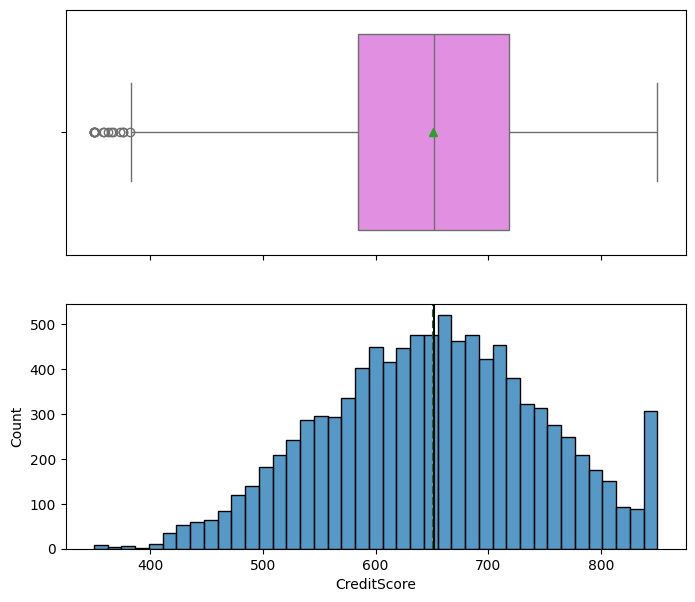

In [18]:
histogram_boxplot(churn_data, "CreditScore")

## 2. How many active members are there with the bank?

In [19]:
churn_data['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [20]:
churn_data['IsActiveMember'].value_counts(normalize=True)

,proportion
IsActiveMember,
1,0.515
0,0.485


## 3. How are the different customer attributes correlated to each other?

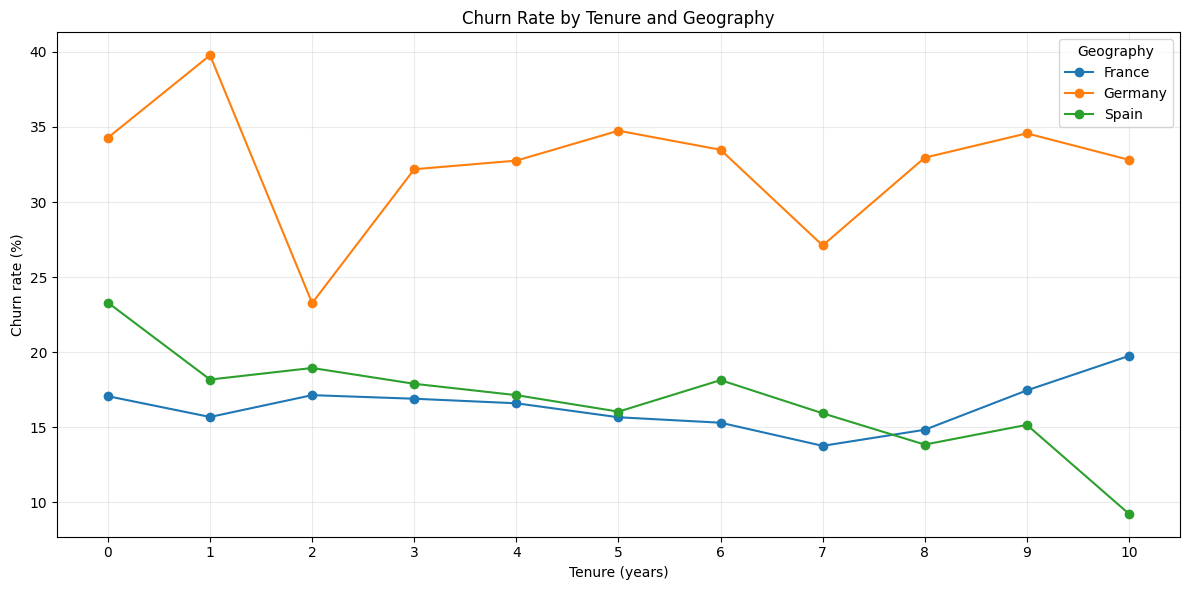

In [21]:
churn_rate = (
    churn_data
    .groupby(["Tenure", "Geography"], observed=True)["Exited"]
    .mean()
    .mul(100)
    .unstack()
)

churn_rate.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Churn Rate by Tenure and Geography")
plt.xlabel("Tenure (years)")
plt.ylabel("Churn rate (%)")
plt.legend(title="Geography")
plt.xticks(sorted(churn_data["Tenure"].unique()))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [22]:
balance_summary = (
    churn_data
    .groupby(["Gender", "Exited"], observed=True)["Balance"]
    .agg(
        customer_count="size",
        mean_balance="mean",
        median_balance="median",
        minimum_balance="min",
        maximum_balance="max"
    )
    .reset_index()
)

balance_summary["Churn"] = balance_summary["Exited"].map({
    0: "No churn",
    1: "Churn"
})

display(balance_summary)

,Gender,Exited,customer_count,mean_balance,median_balance,minimum_balance,maximum_balance,Churn
0,Female,0,3404,71183.250,89967.165,0.000,212778.200,No churn
1,Female,1,1139,89036.639,108076.330,0.000,238387.560,Churn
2,Male,0,4559,73911.607,93911.300,0.000,221532.800,No churn
3,Male,1,898,93736.484,111310.710,0.000,250898.090,Churn


## 4. Who is churning more when compared to males and females?  

In [23]:
gender_churn_rate = (
    churn_data
    .groupby("Gender", observed=True)["Exited"]
    .agg(
        total_customers="size",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)

gender_churn_rate["churn_rate_pct"] = (
    gender_churn_rate["churn_rate"] * 100
)

display(
    gender_churn_rate[
        [
            "Gender",
            "total_customers",
            "churned_customers",
            "churn_rate_pct"
        ]
    ]
)

,Gender,total_customers,churned_customers,churn_rate_pct
0,Female,4543,1139,25.072
1,Male,5457,898,16.456


## 5. Customers from which geographical part are churning more?

In [24]:
geography_churn_rate = (
    churn_data
    .groupby("Geography", observed=True)["Exited"]
    .agg(
        total_customers="size",
        churned_customers="sum",
        churn_rate="mean"
    )
    .reset_index()
)
geography_churn_rate["churn_rate_pct"] = (
    geography_churn_rate["churn_rate"] * 100
)

display(
    geography_churn_rate[
        [
            "Geography",
            "total_customers",
            "churned_customers",
            "churn_rate_pct"
        ]
    ]
)

,Geography,total_customers,churned_customers,churn_rate_pct
0,France,5014,810,16.155
1,Germany,2509,814,32.443
2,Spain,2477,413,16.673


## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

Check missing values

In [25]:
churn_data.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


The dataset contains no missing values across the 14 variables, so no missing-value imputation is required

In [26]:
X = churn_data.drop(
    columns=["Exited"]
).copy()

y = churn_data["Exited"].copy()

In [27]:
from sklearn.model_selection import train_test_split

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=42,
    stratify=y_development
)

In [29]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (6000, 10) (6000,)
Validation: (2000, 10) (2000,)
Test: (2000, 10) (2000,)


In [30]:
gender_mapping = {
    "Female": 0.0,
    "Male": 1.0
}

for dataset in [X_train, X_validation, X_test]:
    dataset["Gender"] = dataset["Gender"].map(gender_mapping)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

categorical_columns = ["Geography"]

binary_columns = [
    "Gender",
    "HasCrCard",
    "IsActiveMember"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "geography",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            "binary",
            "passthrough",
            binary_columns
        )
    ],
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'EstimatedSalary']),
                                ('geography',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Geography']),
                                ('binary', 'passthrough',
                                 ['Gender', 'HasCrCard', 'IsActiveMember'])],
                  verbose_feature_names_out=False)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)

X_validation_processed = preprocessor.transform(X_validation)

X_test_processed = preprocessor.transform(X_test)

In [33]:
X_train_processed = X_train_processed.astype("float32")
X_validation_processed = X_validation_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

y_train = y_train.astype("float32")
y_validation = y_validation.astype("float32")
y_test = y_test.astype("float32")

In [34]:
print(X_train_processed.shape)
print(X_validation_processed.shape)
print(X_test_processed.shape)

assert list(X_train_processed.columns) == list(X_validation_processed.columns)
assert list(X_train_processed.columns) == list(X_test_processed.columns)

(6000, 12)
(2000, 12)
(2000, 12)


## Model Building

### Model Evaluation Criterion

Recall, F1, AUC, precision and accuracy.

### Model Building: Neural Network

In [35]:
def model_performance_classification_sklearn(model, predictors, target):

    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # Accuracy
    recall = recall_score(target, pred)  # Recall
    precision = precision_score(target, pred)  # Precision
    f1 = f1_score(target, pred)  # F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

In [36]:
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):

    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # SUMMARY STATISTICS
    if sum_stats:
        accuracy  = np.trace(cf) / float(np.sum(cf))

    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)


    if title:
        plt.title(title)

In [37]:
def confusion_matrix_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "False Negative Rate": fn / (fn + tp),
        "False Positive Rate": fp / (fp + tn),
        "Recall": tp / (tp + fn),
        "Precision": tp / (tp + fp),
        "Accuracy": (tn + tp) / cm.sum()
    }

In [38]:
model=Sequential()
model.add(Dense(activation = 'relu', input_dim = 12, units=64))
model.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(1, activation = 'sigmoid'))

In [39]:
model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [40]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    ReduceLROnPlateau,
    EarlyStopping
)
checkpoint = ModelCheckpoint(
    filepath="best_model.weights.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, reduce_lr, early_stopping]


In [41]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_validation_processed,
        y_validation
    ),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
182/188 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7052 - loss: 0.5771
Epoch 1: val_loss improved from None to 0.45777, saving model to best_model.weights.h5

Epoch 1: finished saving model to best_model.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7748 - loss: 0.5054 - val_accuracy: 0.7990 - val_loss: 0.4578 - learning_rate: 0.0100
Epoch 2/50
180/188 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7944 - loss: 0.4547
Epoch 2: val_loss improved from 0.45777 to 0.43626, saving model to best_model.weights.h5

Epoch 2: finished saving model to best_model.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7992 - loss: 0.4455 - val_accuracy: 0.8055 - val_loss: 0.4363 - learning_rate: 0.0100
Epoch 3/50
170/188 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8046 - loss: 0.4283
Epoch 3: val_loss improved from 0.43626 to 0.42337, saving model to best_model.weights.h5

Epoch 3: finished saving model to best_model.weights.h5
188/188 ━━━━━━━━━━━━━

In [42]:
y_pred=model.predict(X_validation_processed)
y_pred = (y_pred > 0.6)
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [False]])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3629


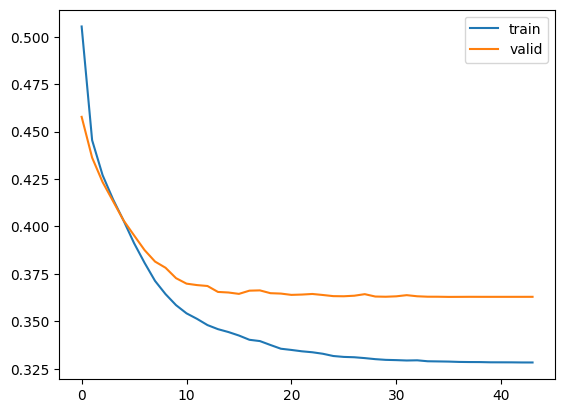

In [43]:
hist  = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model.evaluate(X_validation_processed, y_validation)

In [44]:
from sklearn.metrics import classification_report
report=classification_report(y_validation,y_pred)
print(report)


              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91      1593
         1.0       0.80      0.35      0.49       407

    accuracy                           0.85      2000
   macro avg       0.83      0.67      0.70      2000
weighted avg       0.85      0.85      0.83      2000



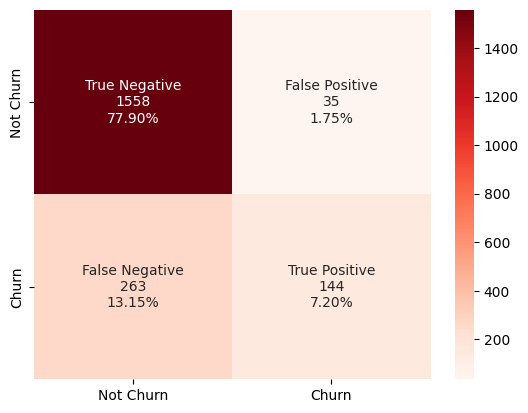

In [45]:
cm=confusion_matrix(y_validation, y_pred)
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

categories = [
    "Not Churn",
    "Churn"
]
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Reds')

### Model Building: Neural Network model with other optimizers

In [46]:
backend.clear_session()
#Fixing the seed for random number generators
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [47]:
model1=Sequential()
model1.add(Dense(activation = 'relu', input_dim = 12, units=64))
model1.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model1.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
model1.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
model1.add(Dense(1, activation = 'sigmoid'))

In [48]:
model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [49]:
callbacks = [checkpoint, reduce_lr]

In [50]:
history1 = model1.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_validation_processed,
        y_validation
    ),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7641 - loss: 0.5121
Epoch 1: val_loss did not improve from 0.36289
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7963 - loss: 0.4544 - val_accuracy: 0.8220 - val_loss: 0.3970 - learning_rate: 0.0010
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8466 - loss: 0.3598
Epoch 2: val_loss improved from 0.36289 to 0.36164, saving model to best_model.weights.h5

Epoch 2: finished saving model to best_model.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8452 - loss: 0.3647 - val_accuracy: 0.8535 - val_loss: 0.3616 - learning_rate: 0.0010
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3286
Epoch 3: val_loss improved from 0.36164 to 0.35528, saving model to best_model.weights.h5

Epoch 3: finished saving model to best_model.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - loss: 0.3418 - val_accuracy: 0.8520 - val_loss: 0.3553 - 

In [51]:
y_pred1=model1.predict(X_validation_processed)
y_pred1 = (y_pred1 > 0.6)
y_pred1

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8525 - loss: 0.3597


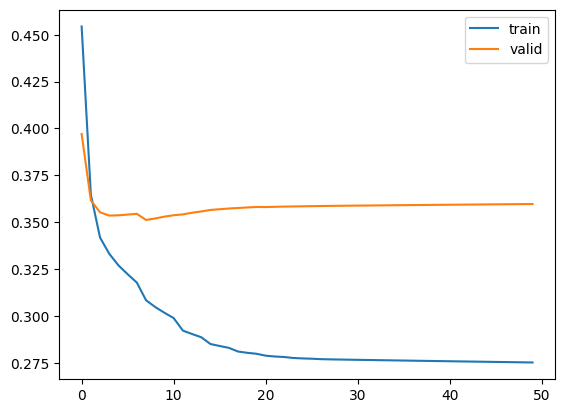

In [52]:
hist  = pd.DataFrame(history1.history)
hist['epoch'] = history1.epoch
hist.tail()
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results1 = model1.evaluate(X_validation_processed, y_validation)

In [53]:
report1=classification_report(y_validation,y_pred1)
print(report1)

              precision    recall  f1-score   support

         0.0       0.87      0.97      0.91      1593
         1.0       0.77      0.41      0.54       407

    accuracy                           0.85      2000
   macro avg       0.82      0.69      0.73      2000
weighted avg       0.85      0.85      0.84      2000



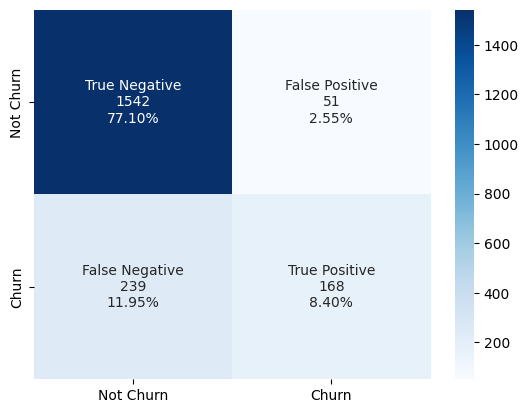

In [54]:
cm=confusion_matrix(y_validation, y_pred1)
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

categories = [
    "Not Churn",
    "Churn"
]
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

### Model Improvement: Neural Network model with Dropout

Adding Dropout to the original Model

In [55]:
backend.clear_session()
#Fixing the seed for random number generators
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [56]:
model2=Sequential()
model2.add(Dense(activation = 'relu', input_dim = 12, units=64))
model2.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model2.add(Dropout(0.5))
model2.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
model2.add(Dropout(0.5))
model2.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
model2.add(Dense(1, activation = 'sigmoid'))

In [57]:
model2.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [58]:
history2 = model2.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_validation_processed,
        y_validation
    ),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7552 - loss: 0.5486 - val_accuracy: 0.7965 - val_loss: 0.4912
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7923 - loss: 0.5061 - val_accuracy: 0.7965 - val_loss: 0.4793
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7948 - loss: 0.4973 - val_accuracy: 0.7965 - val_loss: 0.4709
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7958 - loss: 0.4865 - val_accuracy: 0.7965 - val_loss: 0.4634
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7952 - loss: 0.4765 - val_accuracy: 0.7965 - val_loss: 0.4587
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7958 - loss: 0.4717 - val_accuracy: 0.7965 - val_loss: 0.4539
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7968 - loss: 0.4671 - val_accuracy: 0.7975 - val_loss: 0.4490
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7968 - loss: 0.4638 - val_accuracy: 0.

In [59]:
y_pred2=model2.predict(X_validation_processed)
y_pred2 = (y_pred2 > 0.6)
y_pred2

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8510 - loss: 0.3649


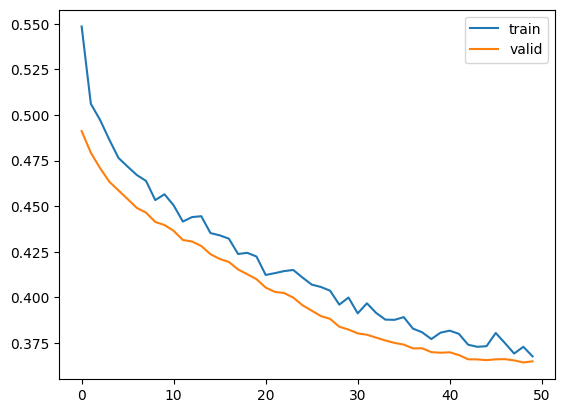

In [60]:
hist  = pd.DataFrame(history2.history)
hist['epoch'] = history2.epoch
hist.tail()
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results2 = model2.evaluate(X_validation_processed, y_validation)

In [61]:
report2=classification_report(y_validation,y_pred2)
print(report2)

              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91      1593
         1.0       0.79      0.30      0.44       407

    accuracy                           0.84      2000
   macro avg       0.82      0.64      0.67      2000
weighted avg       0.83      0.84      0.81      2000



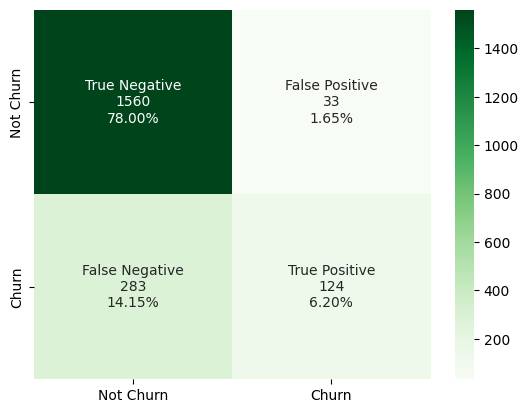

In [62]:
cm=confusion_matrix(y_validation, y_pred2)
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

categories = [
    "Not Churn",
    "Churn"
]
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Greens')

##Model Improvement: Neural Network model with Hyperparameter tuning

In [63]:
import keras
from keras.wrappers import SKLearnClassifier
from sklearn.model_selection import GridSearchCV

In [67]:
backend.clear_session()
np.random.seed(15)
import random
random.seed(15)
tf.random.set_seed(15)

In [68]:
import keras

def create_model(
    X,
    y,
    hidden_unit1=16,
    hidden_unit2=16,
    learning_rate=0.001
):
    model = keras.Sequential([
        keras.Input(shape=(X.shape[1],)),

        keras.layers.Dense(
            hidden_unit1,
            activation="relu",
            kernel_initializer="he_normal"
        ),

        keras.layers.Dense(
            hidden_unit2,
            activation="relu",
            kernel_initializer="he_normal"
        ),

        # Two outputs: no churn and churn
        keras.layers.Dense(
            2,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [69]:
classifier = SKLearnClassifier(
    model=create_model,
    fit_kwargs={
        "verbose": 0
    }
)

In [70]:
model_options = [
    {
        "hidden_unit1": 16,
        "hidden_unit2": 16,
        "learning_rate": 0.001
    },
    {
        "hidden_unit1": 16,
        "hidden_unit2": 32,
        "learning_rate": 0.001
    },
    {
        "hidden_unit1": 32,
        "hidden_unit2": 16,
        "learning_rate": 0.001
    },
    {
        "hidden_unit1": 32,
        "hidden_unit2": 32,
        "learning_rate": 0.001
    }
]

fit_options = [
    {
        "epochs": 20,
        "batch_size": 64,
        "verbose": 0
    },
    {
        "epochs": 20,
        "batch_size": 128,
        "verbose": 0
    }
]

hyperparameters = {
    "model_kwargs": model_options,
    "fit_kwargs": fit_options
}

In [71]:
from sklearn.pipeline import Pipeline

search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

hyperparameters = {
    "classifier__model_kwargs": model_options,
    "classifier__fit_kwargs": fit_options
}

grid = GridSearchCV(
    estimator=search_pipeline,
    param_grid=hyperparameters,
    cv=3,
    scoring="recall",
    verbose=2,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

grid_result = grid.fit(
    X_train,
    y_train.astype("int32")
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[CV] END classifier__fit_kwargs={'epochs': 20, 'batch_size': 64, 'verbose': 0}, classifier__model_kwargs={'hidden_unit1': 16, 'hidden_unit2': 16, 'learning_rate': 0.001}; total time=   7.5s
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[CV] END classifier__fit_kwargs={'epochs': 20, 'batch_size': 64, 'verbose': 0}, classifier__model_kwargs={'hidden_unit1': 16, 'hidden_unit2': 16, 'learning_rate': 0.001}; total time=   5.8s
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[CV] END classifier__fit_kwargs={'epochs': 20, 'batch_size': 64, 'verbose': 0}, classifier__model_kwargs={'hidden_unit1': 16, 'hidden_unit2': 16, 'learning_rate': 0.001}; total time=   4.3s
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[CV] END classifier__fit_kwargs={'epochs': 20, 'batch_size': 64, 'verbose': 0}, classifier__model_kwargs={'hidden_unit1': 16, 'hidden_unit2': 32, 'learning_rate': 0.001}; total time=   4.4s
63/63 ━━━━━━━━━━━━━━━━━━

In [72]:
print("Best cross-validation recall:", grid_result.best_score_)
print("Best parameters:")
print(grid_result.best_params_)

Best cross-validation recall: 0.45216272422154774
Best parameters:
{'classifier__fit_kwargs': {'epochs': 20, 'batch_size': 64, 'verbose': 0}, 'classifier__model_kwargs': {'hidden_unit1': 32, 'hidden_unit2': 16, 'learning_rate': 0.001}}


In [73]:
final_model = create_model(
    X=X_train_processed,
    y=y_train,
    hidden_unit1=32,
    hidden_unit2=32,
    learning_rate=0.001)

final_model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,538 (6.01 KB)

 Trainable params: 1,538 (6.01 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
import keras

y_train_encoded = keras.utils.to_categorical(
    y_train,
    num_classes=2
)

y_validation_encoded = keras.utils.to_categorical(
    y_validation,
    num_classes=2
)

print(y_train_encoded.shape)
print(y_train_encoded[:5])

(6000, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [75]:
final_history = final_model.fit(
    X_train_processed,
    y_train_encoded,
    validation_data=(
        X_validation_processed,
        y_validation_encoded
    ),
    epochs=20,
    batch_size=64,
    verbose=0
)

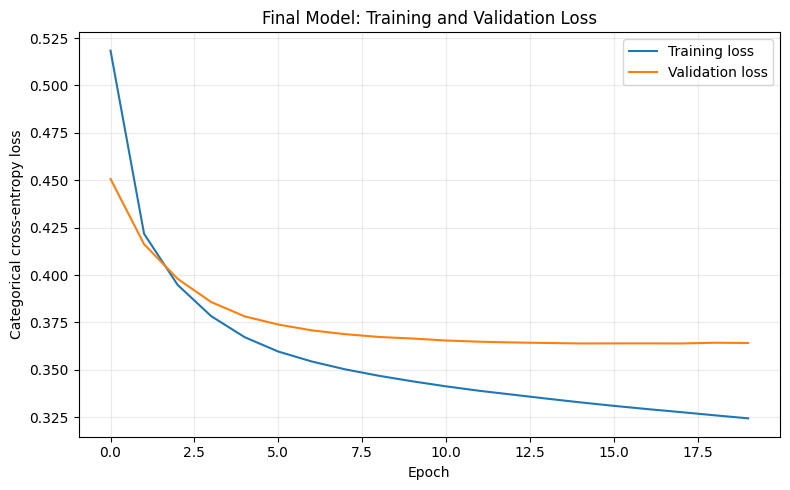

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history["loss"],
    label="Training loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation loss"
)

plt.title("Final Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Categorical cross-entropy loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [77]:
validation_probabilities = final_model.predict(
    X_validation_processed
)

print(validation_probabilities[:5])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0.9845797  0.01542038]
 [0.96967334 0.0303266 ]
 [0.5967379  0.403262  ]
 [0.8384417  0.16155837]
 [0.90884835 0.09115165]]


In [78]:
validation_churn_probability = validation_probabilities[:, 1]

In [79]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(
    y_validation,
    validation_churn_probability
)

g_mean = np.sqrt(tpr * (1 - fpr))
best_threshold_index = np.argmax(g_mean)
selected_threshold = thresholds[best_threshold_index]

print(f"Selected validation threshold: {selected_threshold:.4f}")

Selected validation threshold: 0.1674


In [80]:
test_probabilities = final_model.predict(
    X_test_processed
)

test_churn_probability = test_probabilities[:, 1]

test_predictions = (
    test_churn_probability >= selected_threshold
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [81]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Not Churn", "Churn"]
    )
)

test_cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = test_cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, test_churn_probability)
)

              precision    recall  f1-score   support

   Not Churn       0.93      0.77      0.84      1593
       Churn       0.46      0.77      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000

TN: 1222
FP: 371
FN: 94
TP: 313
Test ROC-AUC: 0.8565422124744158


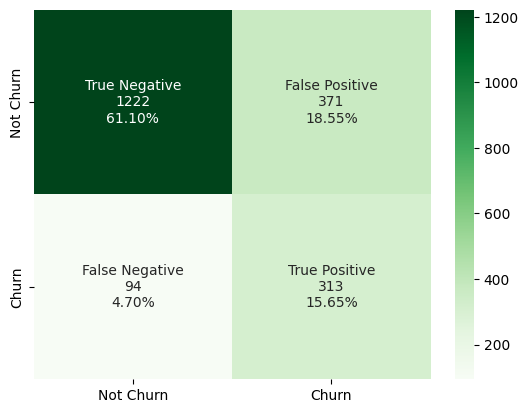

In [82]:
cm=confusion_matrix(y_test,test_predictions)
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

categories = [
    "Not Churn",
    "Churn"
]
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Greens')

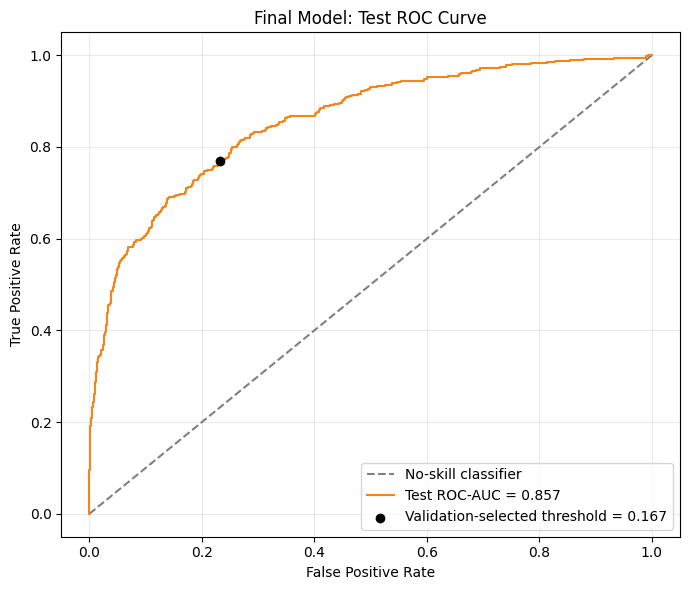

In [83]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

test_fpr, test_tpr, test_thresholds = roc_curve(
    y_test,
    test_churn_probability
)

test_roc_auc = roc_auc_score(y_test, test_churn_probability)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
).ravel()

selected_test_fpr = fp / (fp + tn)
selected_test_tpr = tp / (tp + fn)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="No-skill classifier"
)

plt.plot(
    test_fpr,
    test_tpr,
    color="#F58518",
    label=f"Test ROC-AUC = {test_roc_auc:.3f}"
)

plt.scatter(
    selected_test_fpr,
    selected_test_tpr,
    color="black",
    zorder=3,
    label=f"Validation-selected threshold = {selected_threshold:.3f}"
)

plt.title("Final Model: Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Model Improvement: Neural Network model with balanced data: class weights and SMOTE

These models will be a variant of the GridSearch (named final_model)

In [84]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [85]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.float32(0.0): np.float64(0.6280092108017584), np.float32(1.0): np.float64(2.4529844644317254)}


In [86]:
balanced_model = create_model(
    X=X_train_processed,
    y=y_train,
    hidden_unit1=32,
    hidden_unit2=32,
    learning_rate=0.001)

In [87]:
balanced_checkpoint = ModelCheckpoint(
    filepath="balanced_model.weights.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

balanced_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

balanced_early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

balanced_callbacks = [
    balanced_checkpoint,
    balanced_reduce_lr,
    balanced_early_stopping
]

In [88]:
balanced_history = balanced_model.fit(
    X_train_processed,
    y_train_encoded,
    validation_data=(
        X_validation_processed,
        y_validation_encoded
    ),
    epochs=20,
    batch_size=64,
    callbacks=balanced_callbacks,
    class_weight=class_weights,
    verbose=0
)


Epoch 1: val_loss improved from None to 0.62563, saving model to balanced_model.weights.h5

Epoch 1: finished saving model to balanced_model.weights.h5

Epoch 2: val_loss improved from 0.62563 to 0.59064, saving model to balanced_model.weights.h5

Epoch 2: finished saving model to balanced_model.weights.h5

Epoch 3: val_loss improved from 0.59064 to 0.57018, saving model to balanced_model.weights.h5

Epoch 3: finished saving model to balanced_model.weights.h5

Epoch 4: val_loss improved from 0.57018 to 0.55217, saving model to balanced_model.weights.h5

Epoch 4: finished saving model to balanced_model.weights.h5

Epoch 5: val_loss improved from 0.55217 to 0.53423, saving model to balanced_model.weights.h5

Epoch 5: finished saving model to balanced_model.weights.h5

Epoch 6: val_loss improved from 0.53423 to 0.52420, saving model to balanced_model.weights.h5

Epoch 6: finished saving model to balanced_model.weights.h5

Epoch 7: val_loss improved from 0.52420 to 0.51862, saving model t

In [89]:
from sklearn.metrics import classification_report

# Unbalanced grid-selected model
unbalanced_probability = final_model.predict(
    X_validation_processed
)[:, 1]

unbalanced_prediction = (
    unbalanced_probability >= 0.60
).astype(int)

# Class-weighted model
balanced_probability = balanced_model.predict(
    X_validation_processed
)[:, 1]

balanced_prediction = (
    balanced_probability >= 0.60
).astype(int)

print("UNBALANCED MODEL")
print(
    classification_report(
        y_validation,
        unbalanced_prediction,
        target_names=["Not Churn", "Churn"]
    )
)

print("CLASS-WEIGHTED MODEL")
print(
    classification_report(
        y_validation,
        balanced_prediction,
        target_names=["Not Churn", "Churn"]
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
UNBALANCED MODEL
              precision    recall  f1-score   support

   Not Churn       0.85      0.98      0.91      1593
       Churn       0.80      0.34      0.48       407

    accuracy                           0.85      2000
   macro avg       0.83      0.66      0.69      2000
weighted avg       0.84      0.85      0.82      2000

CLASS-WEIGHTED MODEL
              precision    recall  f1-score   support

   Not Churn       0.91      0.82      0.87      1593
       Churn       0.50      0.70      0.58       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000



In [90]:
from sklearn.metrics import roc_auc_score, average_precision_score

print(
    "Unbalanced ROC-AUC:",
    roc_auc_score(y_validation, unbalanced_probability)
)

print(
    "Balanced ROC-AUC:",
    roc_auc_score(y_validation, balanced_probability)
)

print(
    "Unbalanced PR-AUC:",
    average_precision_score(
        y_validation,
        unbalanced_probability
    )
)

print(
    "Balanced PR-AUC:",
    average_precision_score(
        y_validation,
        balanced_probability
    )
)

Unbalanced ROC-AUC: 0.8428166224776394
Balanced ROC-AUC: 0.8463671684010667
Unbalanced PR-AUC: 0.6508570049727068
Balanced PR-AUC: 0.6545786923334066


In [91]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

y_train_smote_encoded = keras.utils.to_categorical(
    y_train_smote,
    num_classes=2
)

In [92]:
smote_model = create_model(
    X=X_train_smote,
    y=y_train,
    hidden_unit1=32,
    hidden_unit2=32,
    learning_rate=0.001)

In [93]:
smote_model.fit(
    X_train_smote,
    y_train_smote_encoded,
    validation_data=(
        X_validation_processed,
        y_validation_encoded
    ),
    epochs=20,
    batch_size=128,
    verbose=0
)

In [94]:
# Unbalanced grid-selected model
unbalanced_probability = final_model.predict(
    X_validation_processed
)[:, 1]

unbalanced_prediction = (
    unbalanced_probability >= 0.60
).astype(int)

# Class-weighted model
balanced_probability = balanced_model.predict(
    X_validation_processed
)[:, 1]

balanced_prediction = (
    balanced_probability >= 0.60
).astype(int)

#SMOTE model
smote_probability = smote_model.predict(
    X_validation_processed
)[:, 1]

smote_prediction = (
    smote_probability >= 0.60
).astype(int)


print("UNBALANCED MODEL")
print(
    classification_report(
        y_validation,
        unbalanced_prediction,
        target_names=["Not Churn", "Churn"]
    )
)

print("CLASS-WEIGHTED MODEL")
print(
    classification_report(
        y_validation,
        balanced_prediction,
        target_names=["Not Churn", "Churn"]
    )
)

print("SMOTE MODEL")
print(
    classification_report(
        y_validation,
        smote_prediction,
        target_names=["Not Churn", "Churn"]
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
UNBALANCED MODEL
              precision    recall  f1-score   support

   Not Churn       0.85      0.98      0.91      1593
       Churn       0.80      0.34      0.48       407

    accuracy                           0.85      2000
   macro avg       0.83      0.66      0.69      2000
weighted avg       0.84      0.85      0.82      2000

CLASS-WEIGHTED MODEL
              precision    recall  f1-score   support

   Not Churn       0.91      0.82      0.87      1593
       Churn       0.50      0.70      0.58       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000

SMOTE MODEL
              precision    recall  f1-score   support

   Not Churn       0.92      0.84      0.88      1593
       Churn       0.53      0.70      0.60       407

    accuracy   

In [95]:
print(
    "Unbalanced ROC-AUC:",
    roc_auc_score(y_validation, unbalanced_probability)
)

print(
    "Balanced ROC-AUC:",
    roc_auc_score(y_validation, balanced_probability)
)

print(
    "SMOTE ROC-AUC:",
    roc_auc_score(y_validation, smote_probability)
)

print(
    "Unbalanced PR-AUC:",
    average_precision_score(
        y_validation,
        unbalanced_probability
    )
)

print(
    "Balanced PR-AUC:",
    average_precision_score(
        y_validation,
        balanced_probability
    )
)

print(
    "SMOTE PR-AUC:",
    average_precision_score(
        y_validation,
        smote_probability
    )
)

Unbalanced ROC-AUC: 0.8428166224776394
Balanced ROC-AUC: 0.8463671684010667
SMOTE ROC-AUC: 0.8404429082395184
Unbalanced PR-AUC: 0.6508570049727068
Balanced PR-AUC: 0.6545786923334066
SMOTE PR-AUC: 0.66002253360394


## Final Model Comparison

In [96]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    log_loss
)

def model_comparison_row(
    model_name,
    y_true,
    churn_probability,
    threshold=0.50
):
    y_true = np.asarray(y_true).astype(int).ravel()
    churn_probability = np.asarray(
        churn_probability
    ).astype(float).ravel()

    prediction = (
        churn_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    ).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, prediction),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            prediction
        ),
        "Churn Precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "Churn Recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "Churn F1": f1_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "Specificity": tn / (tn + fp),
        "False Negative Rate": fn / (fn + tp),
        "False Positive Rate": fp / (fp + tn),
        "ROC-AUC": roc_auc_score(
            y_true,
            churn_probability
        ),
        "PR-AUC": average_precision_score(
            y_true,
            churn_probability
        ),
        "Log Loss": log_loss(
            y_true,
            np.column_stack([
                1 - churn_probability,
                churn_probability
            ]),
            labels=[0, 1]
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [97]:
comparison_threshold = 0.60

original_probability = model.predict(
    X_validation_processed,
    verbose=0
).ravel()

adam_probability = model1.predict(
    X_validation_processed,
    verbose=0
).ravel()

dropout_probability = model2.predict(
    X_validation_processed,
    verbose=0
).ravel()

first_three_comparison = pd.DataFrame([
    model_comparison_row(
        "Original NN — SGD",
        y_validation,
        original_probability,
        comparison_threshold
    ),
    model_comparison_row(
        "NN — Adam",
        y_validation,
        adam_probability,
        comparison_threshold
    ),
    model_comparison_row(
        "NN — SGD + Dropout",
        y_validation,
        dropout_probability,
        comparison_threshold
    )
])

display(
    first_three_comparison.round(3)
)

,Model,Threshold,Accuracy,Balanced Accuracy,Churn Precision,Churn Recall,Churn F1,Specificity,False Negative Rate,False Positive Rate,ROC-AUC,PR-AUC,Log Loss,TN,FP,FN,TP
0,Original NN — SGD,0.600,0.851,0.666,0.804,0.354,0.491,0.978,0.646,0.022,0.841,0.646,0.363,1558,35,263,144
1,NN — Adam,0.600,0.855,0.690,0.767,0.413,0.537,0.968,0.587,0.032,0.851,0.672,0.360,1542,51,239,168
2,NN — SGD + Dropout,0.600,0.842,0.642,0.790,0.305,0.440,0.979,0.695,0.021,0.848,0.655,0.365,1560,33,283,124


In [98]:
final_probability = final_model.predict(
    X_validation_processed,
    verbose=0
)[:, 1]

balanced_probability = balanced_model.predict(
    X_validation_processed,
    verbose=0
)[:, 1]

smote_probability = smote_model.predict(
    X_validation_processed,
    verbose=0
)[:, 1]

last_three_comparison = pd.DataFrame([
    model_comparison_row(
        "Grid-selected NN",
        y_validation,
        final_probability,
        comparison_threshold
    ),
    model_comparison_row(
        "Grid-selected NN + Class Weights",
        y_validation,
        balanced_probability,
        comparison_threshold
    ),
    model_comparison_row(
        "Grid-selected NN + SMOTE",
        y_validation,
        smote_probability,
        comparison_threshold
    )
])

display(
    last_three_comparison.round(3)
)

,Model,Threshold,Accuracy,Balanced Accuracy,Churn Precision,Churn Recall,Churn F1,Specificity,False Negative Rate,False Positive Rate,ROC-AUC,PR-AUC,Log Loss,TN,FP,FN,TP
0,Grid-selected NN,0.600,0.848,0.659,0.802,0.339,0.477,0.979,0.661,0.021,0.843,0.651,0.364,1559,34,269,138
1,Grid-selected NN + Class Weights,0.600,0.798,0.760,0.503,0.695,0.584,0.824,0.305,0.176,0.846,0.655,0.495,1313,280,124,283
2,Grid-selected NN + SMOTE,0.600,0.814,0.771,0.534,0.698,0.605,0.844,0.302,0.156,0.840,0.660,0.480,1345,248,123,284


Suppose that:

*   Missing one churner costs $500
*   Unnecessarily contacting one non-churner costs $20

Then:
Expected cost = (FN x 500)+(FP x 20)



In [106]:
def evaluate_thresholds(
    model_name,
    y_true,
    churn_probability,
    false_negative_cost,
    false_positive_cost
):
    rows = []

    y_true = np.asarray(y_true).astype(int)
    churn_probability = np.asarray(
        churn_probability
    ).ravel()

    thresholds = np.sort(np.unique(validation_churn_probability))

    for threshold in thresholds:
        prediction = (
            churn_probability >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1]
        ).ravel()

        total_cost = (
            fn * false_negative_cost
            + fp * false_positive_cost
        )

        rows.append({
            "Model": model_name,
            "Threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Recall": recall_score(
                y_true,
                prediction,
                zero_division=0
            ),
            "Precision": precision_score(
                y_true,
                prediction,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                prediction,
                zero_division=0
            ),
            "Customers Flagged": int(prediction.sum()),
            "Flagged Rate": prediction.mean(),
            "Expected Cost": total_cost,
            "Cost per Customer": total_cost / len(y_true)
        })

    return pd.DataFrame(rows)

In [107]:
false_negative_cost = 500
false_positive_cost = 20

final_thresholds = evaluate_thresholds(
    "Grid-selected NN",
    y_validation,
    final_probability,
    false_negative_cost,
    false_positive_cost
)

balanced_thresholds = evaluate_thresholds(
    "Class-weighted NN",
    y_validation,
    balanced_probability,
    false_negative_cost,
    false_positive_cost
)

smote_thresholds = evaluate_thresholds(
    "SMOTE NN",
    y_validation,
    smote_probability,
    false_negative_cost,
    false_positive_cost
)

threshold_results = pd.concat(
    [
        final_thresholds,
        balanced_thresholds,
        smote_thresholds
    ],
    ignore_index=True
)

In [108]:
best_business_result = (
    threshold_results
    .sort_values("Expected Cost")
    .head(10)
)

display(best_business_result.round(3))

,Model,Threshold,TN,FP,FN,TP,Recall,Precision,F1,Customers Flagged,Flagged Rate,Expected Cost,Cost per Customer
3113,Class-weighted NN,0.113,412,1181,8,399,0.980,0.253,0.402,1580,0.790,27620,13.810
3114,Class-weighted NN,0.113,412,1181,8,399,0.980,0.253,0.402,1580,0.790,27620,13.810
3115,Class-weighted NN,0.113,412,1181,8,399,0.980,0.253,0.402,1580,0.790,27620,13.810
3168,Class-weighted NN,0.126,459,1134,10,397,0.975,0.259,0.410,1531,0.766,27680,13.840
3111,Class-weighted NN,0.112,409,1184,8,399,0.980,0.252,0.401,1583,0.792,27680,13.840
3110,Class-weighted NN,0.112,409,1184,8,399,0.980,0.252,0.401,1583,0.792,27680,13.840
3167,Class-weighted NN,0.126,459,1134,10,397,0.975,0.259,0.410,1531,0.766,27680,13.840
3169,Class-weighted NN,0.126,459,1134,10,397,0.975,0.259,0.410,1531,0.766,27680,13.840
3112,Class-weighted NN,0.112,409,1184,8,399,0.980,0.252,0.401,1583,0.792,27680,13.840
3163,Class-weighted NN,0.126,458,1135,10,397,0.975,0.259,0.409,1532,0.766,27700,13.850


In [109]:
print(
    "BALANCED ROC-AUC:",
    roc_auc_score(y_test, balanced_probability)
)

print(
    "BALANCED PR-AUC:",
    average_precision_score(
        y_test,
        balanced_probability
    )
)

BALANCED ROC-AUC: 0.5374727578117409
BALANCED PR-AUC: 0.23498759455898555


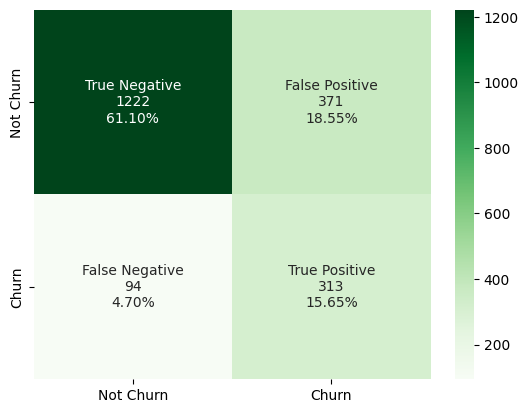

In [115]:
cm1=confusion_matrix(y_test,balanced_prediction)
labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

categories = [
    "Not Churn",
    "Churn"
]
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Greens')

## Permutation Importance and SHAP

In [116]:
#Best Model
best_model = balanced_model

best_model_name = "Grid-selected NN + Class Weights"

In [117]:
import numpy as np
import pandas as pd

def predict_churn_probability(model, X):
    probabilities = np.asarray(
        model.predict(X, verbose=0)
    )

    # Sigmoid model: shape (observations, 1)
    if probabilities.ndim == 2 and probabilities.shape[1] == 1:
        return probabilities[:, 0]

    # Softmax model: column 1 is churn
    if probabilities.ndim == 2 and probabilities.shape[1] == 2:
        return probabilities[:, 1]

    raise ValueError(
        f"Unexpected prediction shape: {probabilities.shape}"
    )

In [118]:
validation_probability = predict_churn_probability(
    best_model,
    X_validation_processed
)

print(validation_probability.shape)
print(validation_probability[:5])

(2000,)
[0.18571867 0.25643224 0.83136743 0.5284618  0.6006885 ]


In [119]:
from sklearn.metrics import average_precision_score

baseline_pr_auc = average_precision_score(
    y_validation,
    validation_probability
)

print(f"Baseline validation PR-AUC: {baseline_pr_auc:.4f}")

Baseline validation PR-AUC: 0.6546


In [120]:
geography_columns = [
    column
    for column in X_validation_processed.columns
    if column.startswith("Geography_")
]

print("Geography columns:", geography_columns)

feature_groups = {
    "CreditScore": ["CreditScore"],
    "Age": ["Age"],
    "Tenure": ["Tenure"],
    "Balance": ["Balance"],
    "NumOfProducts": ["NumOfProducts"],
    "EstimatedSalary": ["EstimatedSalary"],
    "Geography": geography_columns,
    "Gender": ["Gender"],
    "HasCrCard": ["HasCrCard"],
    "IsActiveMember": ["IsActiveMember"]
}

Geography columns: ['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [121]:
print(X_validation_processed.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender', 'HasCrCard', 'IsActiveMember']


In [122]:
rng = np.random.default_rng(42)
number_of_repeats = 20

importance_rows = []

for feature_name, feature_columns in feature_groups.items():
    score_decreases = []

    for repeat in range(number_of_repeats):
        permuted_data = X_validation_processed.copy()

        shuffled_positions = rng.permutation(
            len(permuted_data)
        )

        # Use the same permutation for every column in the group
        permuted_data.loc[:, feature_columns] = (
            permuted_data
            .iloc[shuffled_positions][feature_columns]
            .to_numpy()
        )

        permuted_probability = predict_churn_probability(
            best_model,
            permuted_data
        )

        permuted_pr_auc = average_precision_score(
            y_validation,
            permuted_probability
        )

        score_decreases.append(
            baseline_pr_auc - permuted_pr_auc
        )

    importance_rows.append({
        "Feature": feature_name,
        "Importance": np.mean(score_decreases),
        "Standard Deviation": np.std(score_decreases)
    })

permutation_importance_df = (
    pd.DataFrame(importance_rows)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(permutation_importance_df.round(4))

,Feature,Importance,Standard Deviation
0,NumOfProducts,0.272,0.021
1,Age,0.217,0.015
2,IsActiveMember,0.067,0.008
3,Geography,0.040,0.009
4,Balance,0.040,0.008
5,Tenure,0.004,0.004
6,Gender,0.004,0.004
7,EstimatedSalary,0.004,0.006
8,CreditScore,0.003,0.004
9,HasCrCard,-0.003,0.002


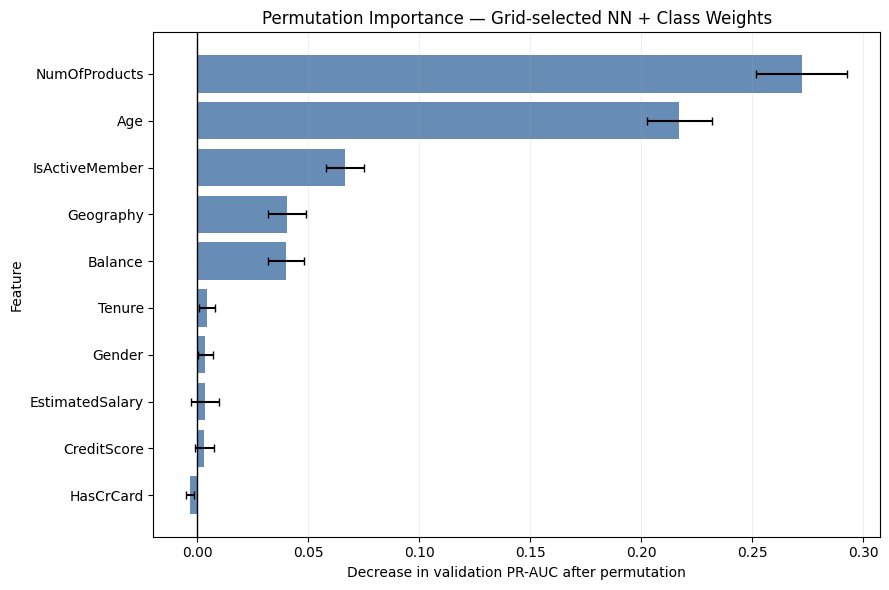

In [123]:
import matplotlib.pyplot as plt

permutation_plot_data = (
    permutation_importance_df
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    permutation_plot_data["Feature"],
    permutation_plot_data["Importance"],
    xerr=permutation_plot_data["Standard Deviation"],
    color="#4C78A8",
    alpha=0.85,
    capsize=3
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    f"Permutation Importance — {best_model_name}"
)

plt.xlabel(
    "Decrease in validation PR-AUC after permutation"
)

plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.20)
plt.tight_layout()
plt.show()

___